<a href="https://colab.research.google.com/github/Aryan-Gupta2002/Deep-Learning---Tensorflow/blob/main/Semantic_Segmentation_PR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9587 - loss: 0.6760
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


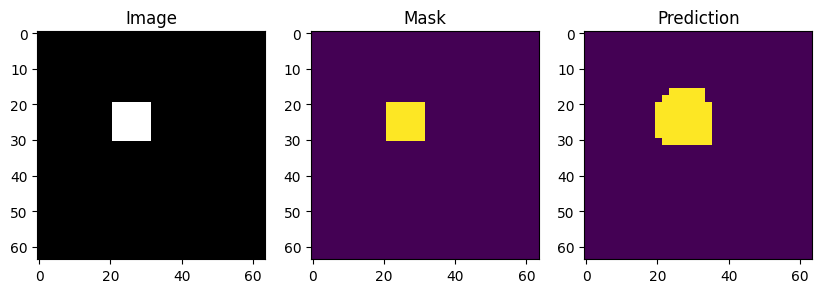

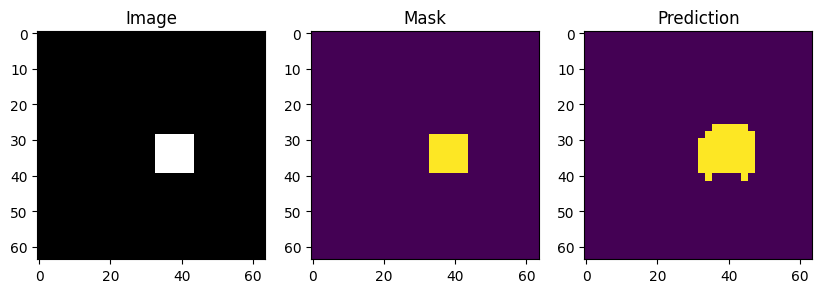

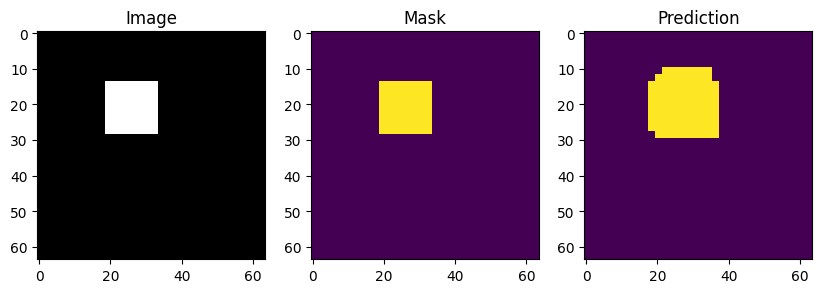

IoU: 0.5610640870616687


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 64
NUM_SAMPLES = 50

images = []
masks = []

for _ in range(NUM_SAMPLES):
    img = np.zeros((IMG_SIZE, IMG_SIZE, 3))
    mask = np.zeros((IMG_SIZE, IMG_SIZE, 1))

    x, y = np.random.randint(10, 40, size=2) # Generates 2 random ints b/w 10-39
    w = np.random.randint(10, 20)

    img[x:x+w, y:y+w] = [1, 1, 1] #[R, G, B] = [1, 1, 1]
    mask[x:x+w, y:y+w] = 1

    images.append(img)
    masks.append(mask)

images = np.array(images)
masks = np.array(masks)

inputs = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3))

x = tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu')(inputs) #params = (filter(outputs),kernel,stride,padding)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.UpSampling2D()(x)

outputs = tf.keras.layers.Conv2D(2, 1, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(images, masks, epochs=1, batch_size=8)

def compute_iou(y_true, y_pred):
    y_pred = np.argmax(y_pred, axis=-1)
    y_true = np.squeeze(y_true)

    intersection = np.logical_and(y_true == 1, y_pred == 1).sum()
    union = np.logical_or(y_true == 1, y_pred == 1).sum()

    return intersection / union if union != 0 else 0

preds = model.predict(images[:3])

for i in range(3):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(images[i])

    plt.subplot(1,3,2)
    plt.title("Mask")
    plt.imshow(masks[i].squeeze())

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(np.argmax(preds[i], axis=-1))

    plt.show()
iou = compute_iou(masks[:3], preds[:3])
print("IoU:", iou)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.QOR4U6_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.QOR4U6_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Epoch 1/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 43s 180ms/step - accuracy: 0.6950 - loss: 0.5844 - val_accuracy: 0.7001 - val_loss: 0.5314
Epoch 2/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 21s 158ms/step - accuracy: 0.7226 - loss: 0.4983 - val_accuracy: 0.7546 - val_loss: 0.4666
Epoch 3/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 39s 150ms/step - accuracy: 0.7506 - loss: 0.4697 - val_accuracy: 0.7552 - val_loss: 0.4626
Epoch 4/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 22s 166ms/step - accuracy: 0.7686 - loss: 0.4550 - val_accuracy: 0.7967 - val_loss: 0.4250
Epoch 5/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 40s 160ms/step - accuracy: 0.7947 - loss: 0.4263 - val_accuracy: 0.8008 - val_loss: 0.4128
115/115 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.8008 - loss: 0.4128
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step


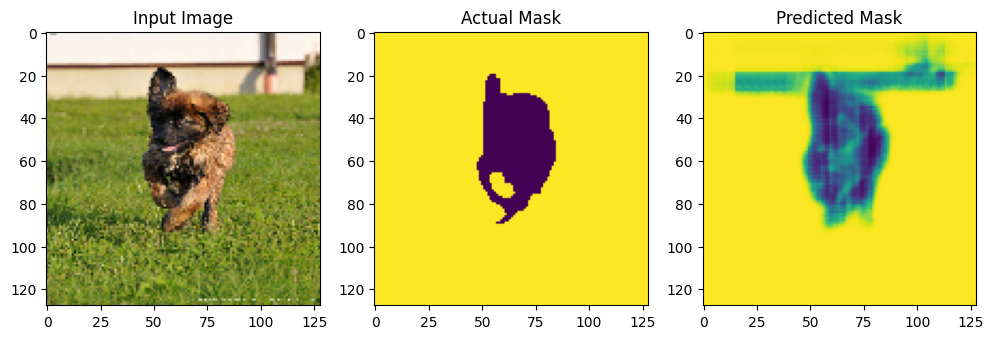

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


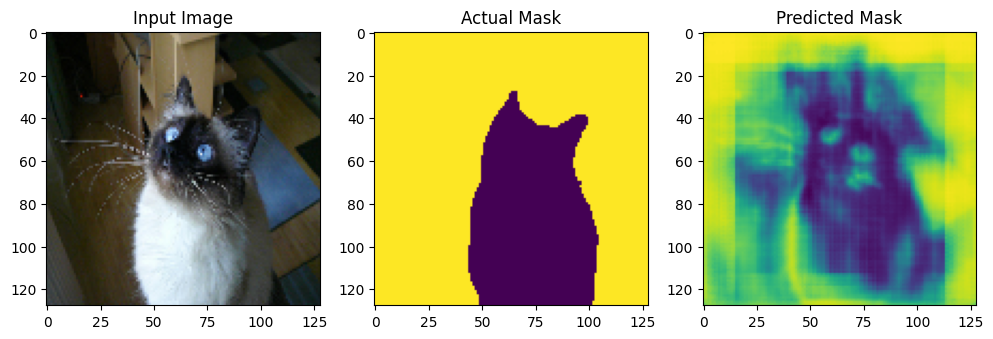

In [ ]:
# Install
!pip install -q tensorflow-datasets


import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt


dataset, info = tfds.load("oxford_iiit_pet", with_info=True)

train_data = dataset['train']
test_data = dataset['test']


IMG_SIZE = 128
BATCH_SIZE = 32

def preprocess(data):
    image = data['image']
    mask = data['segmentation_mask']


    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE), method='nearest')

    image = image / 255.0

    mask = tf.cast(mask > 1, tf.float32)

    return image, mask

train_dataset = train_data.map(preprocess).shuffle(1000).batch(BATCH_SIZE)
test_dataset = test_data.map(preprocess).batch(BATCH_SIZE)


from tensorflow.keras import layers, Model

def unet():
    inputs = layers.Input((128,128,3))


    c1 = layers.Conv2D(16,3,activation='relu',padding='same')(inputs)
    c1 = layers.Conv2D(16,3,activation='relu',padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32,3,activation='relu',padding='same')(p1)
    c2 = layers.Conv2D(32,3,activation='relu',padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)


    c3 = layers.Conv2D(64,3,activation='relu',padding='same')(p2)
    c3 = layers.Conv2D(64,3,activation='relu',padding='same')(c3)


    u1 = layers.Conv2DTranspose(32,2,strides=2,padding='same')(c3)                   #upcolv,concatenate u1&
    u1 = layers.concatenate([u1, c2])
    c4 = layers.Conv2D(32,3,activation='relu',padding='same')(u1)

    u2 = layers.Conv2DTranspose(16,2,strides=2,padding='same')(c4)
    u2 = layers.concatenate([u2, c1])
    c5 = layers.Conv2D(16,3,activation='relu',padding='same')(u2)

    outputs = layers.Conv2D(1,1,activation='sigmoid')(c5)

    return Model(inputs, outputs)


model = unet()


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=test_dataset
)


model.evaluate(test_dataset)


def iou(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return intersection / (union + 1e-7)


for img, mask in test_dataset.take(2):
    pred = model.predict(img)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img[0])
    plt.title("Input Image")

    plt.subplot(1,3,2)
    plt.imshow(mask[0])
    plt.title("Actual Mask")

    plt.subplot(1,3,3)
    plt.imshow(pred[0])
    plt.title("Predicted Mask")

    plt.show()